# Blog figure: held-out performance across full fine-tuning epochs

## imports

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from figutils import cm, set_figure_style

set_figure_style()

OUTPUT_DIR = os.path.join("pdfs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

## data

In [2]:
ROOT        = ".."
RESULTS_DIR = os.path.join(ROOT, "results")

# "probing" (frozen linear-probe) results were computed on BSC; "lora" (constant-lr LoRA) locally
EVAL_DIR_BSC = os.path.join(RESULTS_DIR, "bsc", "evaluation", "alphagenome_pytorch", "full")
EVAL_DIR     = os.path.join(RESULTS_DIR, "evaluation", "alphagenome_pytorch", "full")

# Both runs, mapped to short display labels
RUNS_OI = {
    "randinit__newloss__annotated__frozen__multigpu_ddp":     "probing",
    "randinit__newloss__annotated__lora__largegpu__nowarmup": "lora",
}
RUN_EVAL_DIR = {
    "randinit__newloss__annotated__frozen__multigpu_ddp":     EVAL_DIR_BSC,
    "randinit__newloss__annotated__lora__largegpu__nowarmup": EVAL_DIR,
}

EPOCHS_OI  = [1, 2, 3, 4, 5, 10]
SUBSETS_OI = ["test", "train_sample"]

In [3]:
# Metrics across epochs and subsets for both runs (mirrors figures/finetuning_full.ipynb)
metrics_epochs = []
for run_name, run_label in RUNS_OI.items():
    eval_dir = RUN_EVAL_DIR[run_name]
    for epoch in EPOCHS_OI:
        for subset in SUBSETS_OI:
            fpath = os.path.join(eval_dir, run_name, "epoch{}".format(epoch), subset, "metrics.parquet")
            if os.path.exists(fpath):
                df = pd.read_parquet(fpath)
                df["run_name"]  = run_name
                df["run_label"] = run_label
                df["epoch"]     = epoch
                df["subset"]    = subset
                metrics_epochs.append(df)
metrics_epochs = pd.concat(metrics_epochs, ignore_index=True)
print("metrics rows:", len(metrics_epochs))
print(metrics_epochs.value_counts(["run_label", "subset"]))

metrics rows: 1338
run_label  subset      
probing    test            336
           train_sample    336
lora       train_sample    336
           test            330
Name: count, dtype: int64


## figure

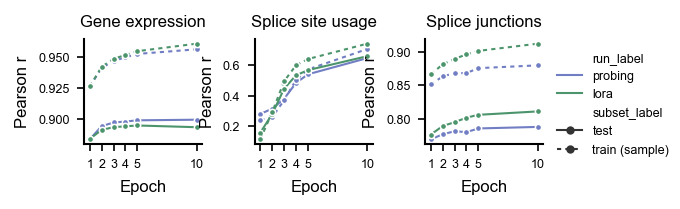

In [4]:
# One representative Pearson r metric per modality, matching the practical-recipe
# table in the blog post
METRIC_MAP = {
    "gene_expr_raw_mean":            "Gene expression",
    "ssu_pearson_r_mean":            "Splice site usage",
    "junction_count_pearson_r_mean": "Splice junctions",
}
METRIC_ORDER = ["Gene expression", "Splice site usage", "Splice junctions"]

# Same model palette as figures/paper.ipynb, for visual consistency across blog figures
MODEL_ORDER = ["probing", "lora"]
PAL_MODELS  = {"probing": "#717EC3", "lora": "#4C956C"}

SUBSET_LABELS = {"test": "test", "train_sample": "train (sample)"}
SUBSET_ORDER  = ["test", "train (sample)"]

x = metrics_epochs[metrics_epochs["metric_name"].isin(METRIC_MAP)].copy()
x["metric_label"] = x["metric_name"].map(METRIC_MAP)
x["subset_label"] = x["subset"].map(SUBSET_LABELS)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch", y="value",
    hue="run_label", hue_order=MODEL_ORDER, palette=PAL_MODELS,
    style="subset_label", style_order=SUBSET_ORDER,
    dashes={"test": "", "train (sample)": (2, 2)},
    markers={"test": "o", "train (sample)": "o"},
    col="metric_label", col_order=METRIC_ORDER,
    linewidth=1, markersize=3,
    facet_kws=dict(sharey=False),
    height=3.5 * cm, aspect=0.9,
)
g.set(xlabel="Epoch", ylabel="Pearson r")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_xticks(EPOCHS_OI)
g.legend.set_title("")

g.fig.savefig(os.path.join(OUTPUT_DIR, "blog_held_out_performance-line.pdf"), bbox_inches="tight", dpi=200)

plt.show()